<a href="https://colab.research.google.com/github/AndresMontesDeOca/AnalisisDatos2/blob/main/Entregas/Actividad2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actividad #2 - Calidad, drift y anomalías

# 0 Libraries & Data Load

In [10]:
# !pip install mlcroissant
# !pip install great_expectations
# !pip install evidently

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mlcroissant as mlc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

# import shap

# Configuración visual
sns.set_theme(style="whitegrid")

# Desactivar la notación científica en Pandas (muestra hasta 2 decimales normales)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [5]:
import mlcroissant as mlc

# Fetch the Croissant JSON-LD
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023/croissant/download')

# Check what record sets are in the dataset
record_sets = croissant_dataset.metadata.record_sets
print(record_sets)

# Fetch the records and put them in a DataFrame
data = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))# Esto elimina el prefijo incluyendo la barra "/" o "\" en cualquier dirección
data.columns = data.columns.str.replace(r'^/?ds_salaries\.csv/?', '', regex=True)


# Seleccionamos todas las columnas que son de tipo texto (object)
columnas_texto = data.select_dtypes(include=['object']).columns

# Recorremos esas columnas y decodificamos los bytes a texto normal (utf-8)
for col in columnas_texto:
    data[col] = data[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# # Volvemos a ver cómo quedó
# data.head()


# print(data.info())
# display(data.head())



  -  [Metadata(Data Science Salaries 2023 💸)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


[RecordSet(uuid="ds_salaries.csv")]


In [6]:
data_dev = data.query("work_year <= 2021")
print(data_dev["work_year"].value_counts())

data_prod = data.query("work_year > 2021")
print(data_prod["work_year"].value_counts())


work_year
2021    230
2020     76
Name: count, dtype: int64
work_year
2023    1785
2022    1664
Name: count, dtype: int64


# 1 - Calidad y Drift

##### 1.a Elegir 3-4 variables relevantes (por ej. salary_in_usd, experience_level, remote_ratio, company_size) y aplicar al menos 3 chequeos de calidad a elección

In [7]:
import great_expectations as gx

variables_evaluacion = [
    "salary_in_usd",
    "remote_ratio",
    "company_size",
    "experience_level",
]


# 1. Configuración del contexto y batch para datos Actuales (PROD: 2022-2023)
context = gx.get_context()
data_source = context.data_sources.add_pandas("pandas_source")
asset = data_source.add_dataframe_asset(name="asset_salarios_prod")
batch_def = asset.add_batch_definition_whole_dataframe("batch_def_prod")
batch_prod = batch_def.get_batch(batch_parameters={"dataframe": data_prod})

# 2. Chequeos de calidad sobre 4 variables relevantes

# a. Completitud (salary_in_usd): Verificamos que no existan valores nulos
res_completitud = batch_prod.validate(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="salary_in_usd")
)
print(f"Completitud (salary_in_usd): {res_completitud.success}")

# b. Validez de Rango (remote_ratio): Asegurar que los valores sean lógicos (0, 50, 100)
res_consistencia = batch_prod.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(column="remote_ratio", value_set=[0, 50, 100])
)
print(f"Validez Dominio (remote_ratio): {res_consistencia.success}")

# c. Validez de Categoría (company_size): Confirmar que respeta las categorías esperadas
res_categoria_size = batch_prod.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(column="company_size", value_set=["S", "M", "L"])
)
print(f"Validez Categoría (company_size): {res_categoria_size.success}")

# d. Validez de Categoría (experience_level): Niveles estándar
res_categoria_exp = batch_prod.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(column="experience_level", value_set=["EN", "MI", "SE", "EX"])
)
print(f"Validez Categoría (experience_level): {res_categoria_exp.success}")

INFO:great_expectations.data_context.types.base:Created temporary directory '/tmp/tmp_enejm2k' for ephemeral docs site


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (salary_in_usd): True


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez Dominio (remote_ratio): True


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez Categoría (company_size): True


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez Categoría (experience_level): True


##### 1.b Sobre las mismas variables, calcular PSI comparando la distribución de referencia vs. la actual

In [11]:
from evidently import Dataset, DataDefinition, Report
from evidently.presets import DataDriftPreset


ref_df = data_dev[variables_evaluacion].copy()
prod_df = data_prod[variables_evaluacion].copy()

definition = DataDefinition(
    numerical_columns=["salary_in_usd"],
    categorical_columns=["remote_ratio", "company_size", "experience_level"],
)

ref = Dataset.from_pandas(ref_df, data_definition=definition)
prod = Dataset.from_pandas(prod_df, data_definition=definition)

report = Report([
    DataDriftPreset(method="psi", threshold=0.2)
])

resultado = report.run(current_data=prod, reference_data=ref)
# resultado # Se rompe la renderizacion si lo muestro, pego imagen abajo

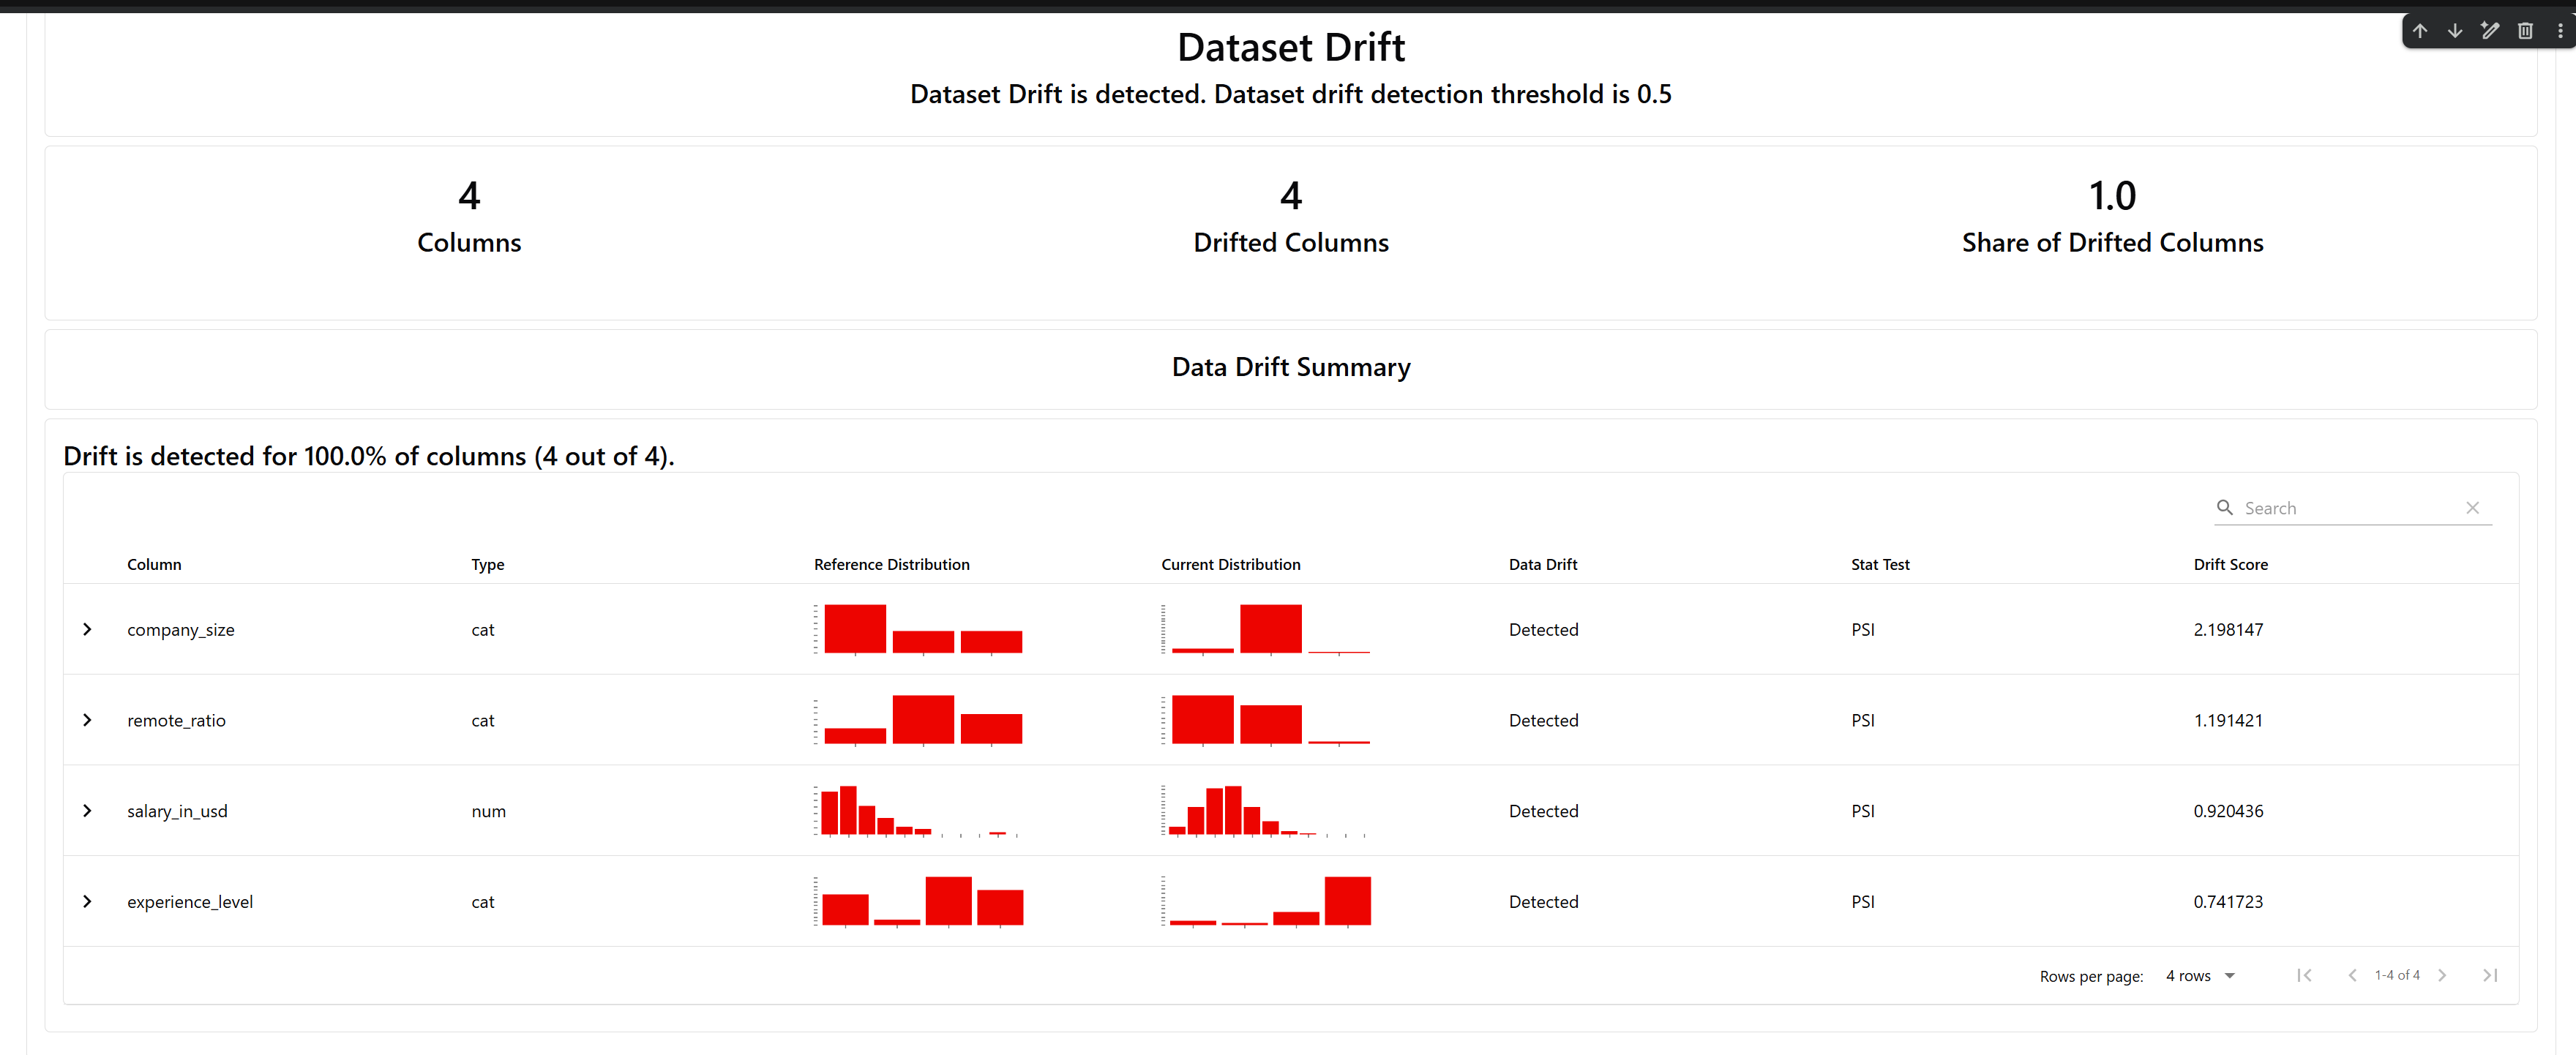

##### 1.c Conclusiones - Análisis de Drift

**1. Desbalance en los datos (Observación previa):**
Hay una diferencia enorme de volumen entre ambos períodos:
* **Referencia (2020-2021):** 306 registros (~8% del total).
* **Actual (2022-2023):** 3.449 registros (~92% del total).

Tener tan pocos datos en la referencia amplifica matemáticamente los valores de PSI. Parte del drift detectado se debe a este sesgo de recolección (la encuesta se masificó en los últimos años) y no solo a cambios reales del mercado.

**2. Análisis por variable (Umbral: PSI >= 0.2 indica drift significativo):**
Como todas superan ampliamente 0.2, detectamos drift en el 100% de las variables:

* **`company_size` (PSI = 2.20 - *Covariate Drift*):** Drift muy severo. En 2020-2021 predominaban empresas grandes (L) y chicas (S), mientras que en 2022-2023 la gran mayoría son medianas (M).
* **`remote_ratio` (PSI = 1.19 - *Covariate Drift*):** En pandemia (2020-2021) el trabajo 100% remoto era dominante; en 2022-2023 creció la presencialidad y el formato híbrido.
* **`salary_in_usd` (PSI = 0.92 - *Target Drift*):** Los salarios se desplazaron hacia la derecha (valores más altos en 2022-2023 por inflación y demanda en tech). Al ser el target del modelo, es Target Drift.
* **`experience_level` (PSI = 0.74 - *Covariate Drift*):** En el período actual hay mucha mayor concentración de perfiles Senior (SE) y Ejecutivos (EX) en comparación con el inicio.


##### 1.d Conclusiones - Estrategia frente al Drift detectado

**Estrategia elegida:** **Reentrenamiento (con ventana deslizante / datos recientes)**

**Justificación:**
1. **Limitación de Random Forest para extrapolar:** En la Actividad 1 entrenamos un `RandomForestRegressor` para predecir `salary_in_usd`. Los modelos basados en árboles no pueden predecir valores fuera del rango visto en el entrenamiento. Al haber un *Target Drift* donde los salarios de 2022-2023 subieron significativamente, el modelo viejo va a subestimar sistemáticamente los sueldos actuales.
2. **Volumen de datos (306 vs 3.449):** La referencia (2020-2021) tiene apenas 306 filas y refleja un contexto atípico de pandemia. El período actual (2022-2023) cuenta con más del 91% de los datos (3.449 filas), capturando mucha mejor variedad de empresas medianas y roles senior. Lo más razonable es descartar la ventana vieja y **reentrenar el modelo directamente con los datos de 2022-2023** (o ponderar por fecha dando mucho mayor peso a los años recientes).


# 2 - Deteccion de Anomalias

##### 2.a Aplicar Isolation Forest y LOF sobre el dataset, usando variables relevantes.

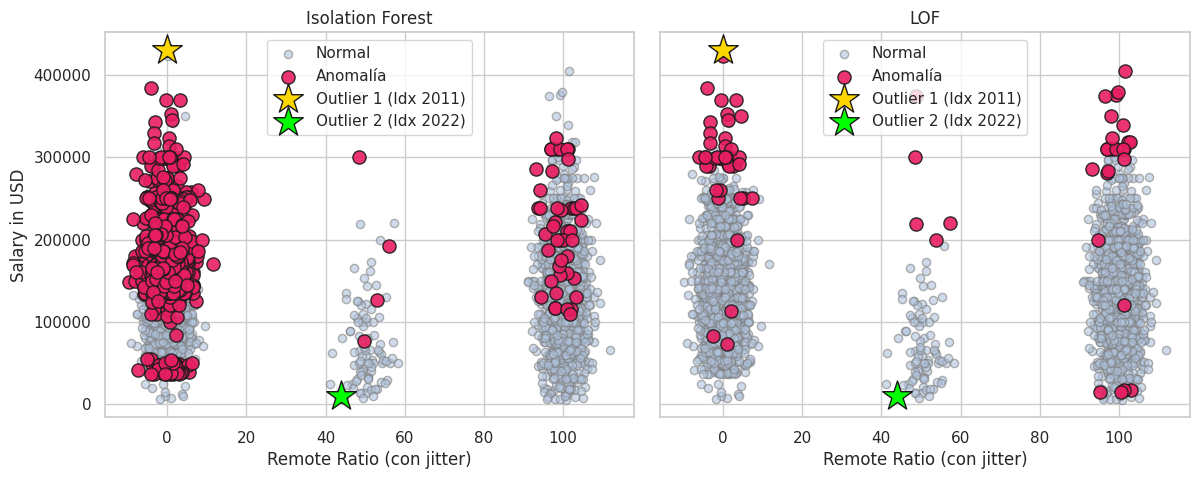

,salary_in_usd,remote_ratio,company_size,experience_level,IF_anomaly,LOF_anomaly
2011,430967,0,M,MI,-1,-1
2022,10000,50,S,SE,-1,1


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 1. Preprocesamiento
variables = ["salary_in_usd", "remote_ratio", "company_size", "experience_level"]
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ["salary_in_usd"]),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ["remote_ratio", "company_size", "experience_level"])
])

X_dev_prep = preprocessor.fit_transform(data_dev[variables])
X_prod_prep = preprocessor.transform(data_prod[variables])

# 2. Modelos
preds_if = IsolationForest(contamination=0.05, random_state=42).fit(X_dev_prep).predict(X_prod_prep)
preds_lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True).fit(X_dev_prep).predict(X_prod_prep)

data_prod_anomalias = data_prod.copy()
data_prod_anomalias['IF_anomaly'] = preds_if
data_prod_anomalias['LOF_anomaly'] = preds_lof

# 3. Preparar Jitter para el gráfico
np.random.seed(42)
x_plot = data_prod_anomalias['remote_ratio'] + np.random.normal(0, 3, size=len(data_prod_anomalias))
y_plot = data_prod_anomalias['salary_in_usd']

# 4. PLOT con Outliers Destacados
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
idx1, idx2 = 2011, 2022 # Los dos outliers elegidos

for i, ax in enumerate(axes):
    col = 'IF_anomaly' if i == 0 else 'LOF_anomaly'
    ax.scatter(x_plot[data_prod_anomalias[col] == 1], y_plot[data_prod_anomalias[col] == 1],
               alpha=0.6, edgecolor='gray', color='lightsteelblue', s=35, label='Normal')
    ax.scatter(x_plot[data_prod_anomalias[col] == -1], y_plot[data_prod_anomalias[col] == -1],
               alpha=0.9, edgecolor='k', color='#E91E63', s=90, label='Anomalía')

    # Destacamos los dos outliers
    ax.scatter(x_plot.loc[idx1], y_plot.loc[idx1], marker='*', s=500, color='gold', edgecolor='k', zorder=5, label='Outlier 1 (Idx 2011)')
    ax.scatter(x_plot.loc[idx2], y_plot.loc[idx2], marker='*', s=500, color='lime', edgecolor='k', zorder=5, label='Outlier 2 (Idx 2022)')

    ax.set_xlabel('Remote Ratio (con jitter)')
    ax.set_title('Isolation Forest' if i == 0 else 'LOF')
    if i == 0: ax.set_ylabel('Salary in USD')
    ax.legend()

plt.subplots_adjust(wspace=0.05)
plt.show()

# Imprimimos la data real de los dos elegidos
display(data_prod_anomalias.loc[[idx1, idx2], variables + ['IF_anomaly', 'LOF_anomaly']])


##### 2.b Identificación de registros anómalos
Elegimos dos outliers muy claros (marcados con estrellas en el gráfico) para analizarlos:
* **Outlier 1 (Estrella Amarilla - Índice 2011):** Gana **430.967 USD**. Nivel Mid-level (`MI`), en empresa mediana (`M`), trabajo 100% presencial (ratio 0).
* **Outlier 2 (Estrella Verde - Índice 2022):** Gana apenas **10.000 USD**. Nivel Senior (`SE`), en empresa pequeña (`S`), formato híbrido (ratio 50).


##### 2.c Para estos registro: ¿es un outlier univariado o multivariado? Justificar mirando los valores reales del registro.
Ambos son **outliers multivariados**.
* **Outlier 1 (Estrella Amarilla):** Si bien su sueldo altísimo casi lo hace un outlier univariado, es la combinación de ganar **casi medio millón de dólares** siendo un perfil intermedio (`MI`) en una empresa mediana (`M`) lo que rompe por completo el patrón (muy probablemente un error de carga).
* **Outlier 2 (Estrella Verde):** Cobrar 10.000 USD al año es matemáticamente posible, y ser Senior existe, pero la combinación simultánea de **salario bajísimo con un rol de altísima jerarquía** (`SE`) rompe el comportamiento "normal" del mercado.


##### 2.d Comparación Isolation Forest vs LOF

* **Outlier 1 (Estrella Amarilla): SÍ coinciden.**
Ambos modelos le asignan `-1` (anomalía). Este registro es tan extremo y alejado del resto de los sueldos que **Isolation Forest** lo aísla enseguida globalmente (pocos cortes en los árboles) y **LOF** lo detecta porque la densidad en su zona local es casi nula (no hay nadie similar con ese sueldo).

* **Outlier 2 (Estrella Verde): NO coinciden.**
**Isolation Forest** lo marca como anomalía (`-1`) porque a nivel general ganar tan poco siendo Senior es atípico. Sin embargo, **LOF** lo considera normal (`1`). Esto se debe a la lógica "local" de LOF: seguramente en la zona de "empresas chicas (`S`) que pagan poco en monedas extranjeras devaluadas" tiene vecinos lo suficientemente cerca como para que su densidad local sea "normal" dentro de su propio micro-grupo.
